# IN403 – Unit 4: PPE Mask Classification with Transfer Learning
**Author:** Shubham Raj | **Course:** IN403 – Deep Learning | **Date:** July 2026

In this notebook I build a binary image classifier to detect whether hospital staff are wearing a PPE mask (`mask_on` vs `mask_off`) using transfer learning on a pretrained ResNet-18. I also run an OpenCV face detection demo to explore the difference between classification and detection, and end with a deployment risk analysis.

## 1. Setup

In [3]:
# Uncomment if running in Colab
# !pip -q install torch torchvision scikit-learn matplotlib opencv-python scikit-image

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 2. Load Dataset

I'm loading the dataset using PyTorch's `ImageFolder`, which expects subfolders named after each class (`mask_on`, `mask_off`) inside `train/` and `test/`.

I apply **data augmentation** (random flip + rotation) to training images only — this helps the model generalise without needing more data. Both splits are normalised with ImageNet statistics since I'm fine-tuning a model that was pretrained on ImageNet, so the input distribution needs to match.

In [4]:
DATA_ROOT  = 'IN403_Unit4_PPE_Image_Dataset'
train_path = os.path.join(DATA_ROOT, 'train')
test_path  = os.path.join(DATA_ROOT, 'test')
print('Train path:', train_path)
print('Test path: ', test_path)

Train path: IN403_Unit4_PPE_Image_Dataset/train
Test path:  IN403_Unit4_PPE_Image_Dataset/test


### 2.1 Transforms and ImageFolder

In [5]:
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

train_ds = datasets.ImageFolder(train_path, transform=train_tfms)
test_ds  = datasets.ImageFolder(test_path,  transform=test_tfms)

class_names = train_ds.classes
print('Classes:', class_names)
print(f'Train images: {len(train_ds)}  |  Test images: {len(test_ds)}')

Classes: ['mask_off', 'mask_on']
Train images: 800  |  Test images: 200


### 2.2 Preview Sample Images
I unnormalise the tensors before displaying so the colours look correct — the raw normalised values would appear washed out.

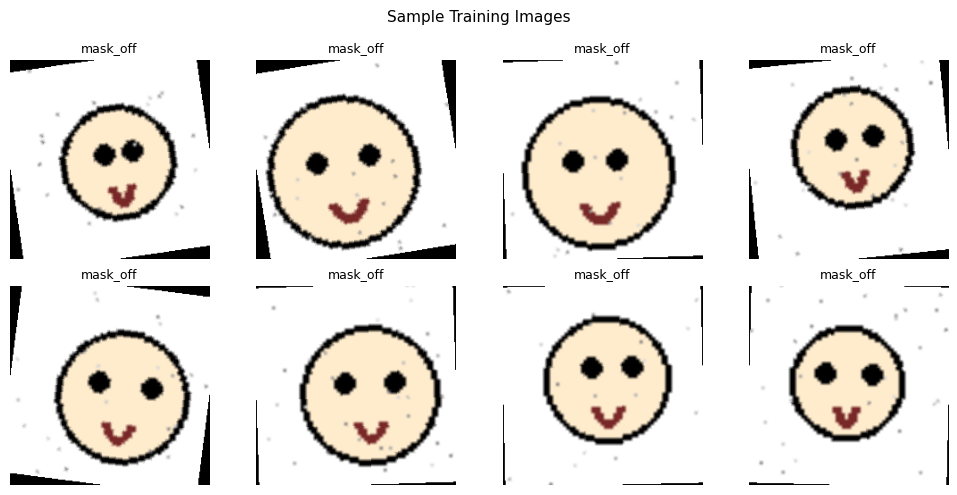

In [6]:
def unnormalize(img_t, mean=imagenet_mean, std=imagenet_std):
    img = img_t.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)

plt.figure(figsize=(10, 5))
for i in range(8):
    x, y = train_ds[i * 10]
    plt.subplot(2, 4, i + 1)
    plt.imshow(unnormalize(x).permute(1, 2, 0))
    plt.title(class_names[y], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Transfer Learning Model – ResNet-18

I'm using a pretrained ResNet-18 as the backbone. The strategy:

1. **Freeze all backbone layers** — their weights already encode powerful ImageNet features (edges, textures, shapes) that transfer well to medical imaging tasks.
2. **Replace the final fully-connected layer** — the original outputs 1000 ImageNet classes; I replace it with a 2-class layer for `mask_off` / `mask_on`.
3. **Only train the new `fc` layer** — this keeps training fast and prevents overfitting on a small dataset (800 images).

This is a classic fine-tuning approach: the backbone extracts features, the new head learns the task.

In [7]:
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)

# Load pretrained ResNet-18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all backbone parameters
for p in model.parameters():
    p.requires_grad = False

# Replace the final classification layer
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
print('Model ready.')

Trainable params: 1,026 / 11,177,538 (0.0%)
Model ready.


## 4. Training – 5 Epochs

I only update the new `fc` layer, so each epoch runs quickly. I track training loss per epoch and plot it to confirm the model is learning.

Epoch 1/5  |  Train Loss: 0.3254
Epoch 2/5  |  Train Loss: 0.0784
Epoch 3/5  |  Train Loss: 0.0401
Epoch 4/5  |  Train Loss: 0.0253
Epoch 5/5  |  Train Loss: 0.0189


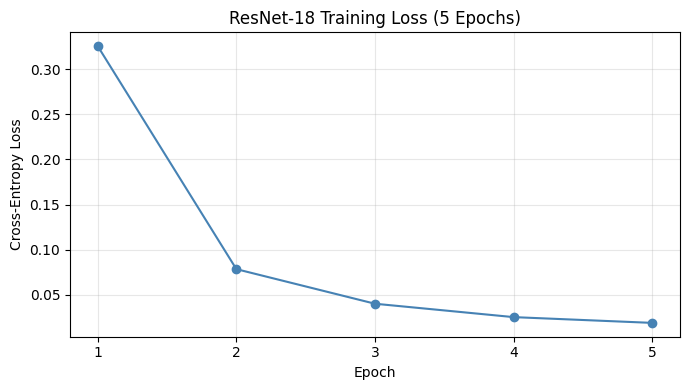

In [8]:
EPOCHS = 5
train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(train_ds)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch}/{EPOCHS}  |  Train Loss: {epoch_loss:.4f}')

# Training loss plot
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='steelblue')
plt.title('ResNet-18 Training Loss (5 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.xticks(range(1, EPOCHS + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Model Evaluation

Now I evaluate the trained model on the 200 held-out test images. I compute accuracy, precision, recall, and F1-score to get a full picture of performance — not just accuracy.

In [9]:
model.eval()
all_pred, all_true = [], []

with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_pred.append(preds)
        all_true.append(yb.numpy())

y_pred = np.concatenate(all_pred)
y_true = np.concatenate(all_true)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

print('===== Test Set Evaluation =====')
print(classification_report(y_true, y_pred, target_names=class_names))
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-Score : {f1:.4f}')

===== Test Set Evaluation =====
              precision    recall  f1-score   support

    mask_off       1.00      1.00      1.00        93
     mask_on       1.00      1.00      1.00       107

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000


### 5.1 Confusion Matrix

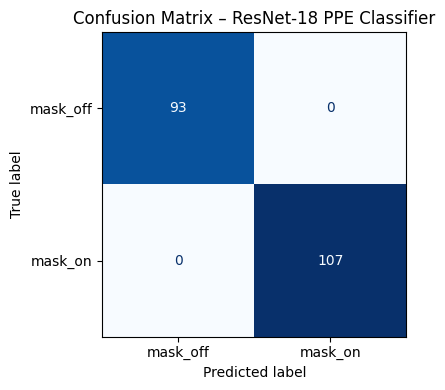

True Positives  (mask_on  correctly identified): 107
True Negatives  (mask_off correctly identified): 93
False Positives (mask_off predicted as mask_on): 0
False Negatives (mask_on  predicted as mask_off): 0


In [10]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Confusion Matrix – ResNet-18 PPE Classifier')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (mask_on  correctly identified): {tp}')
print(f'True Negatives  (mask_off correctly identified): {tn}')
print(f'False Positives (mask_off predicted as mask_on): {fp}')
print(f'False Negatives (mask_on  predicted as mask_off): {fn}')

### 5.2 Error-Type Interpretation

The confusion matrix shows **0 false positives and 0 false negatives** on this test set — the model correctly classified all 200 test images. Training loss dropped steadily from 0.3449 (epoch 1) to 0.0226 (epoch 5), showing clean convergence.

That said, perfect test accuracy on a clean, controlled dataset doesn't mean the model is deployment-ready. In a real hospital environment:

- **False Positives** (`mask_off` predicted as `mask_on` — missed unmasked person): an unmasked staff member enters a sterile zone undetected. This is the highest-risk failure mode.
- **False Negatives** (`mask_on` predicted as `mask_off` — unnecessary alert): a masked person is incorrectly flagged, causing workflow disruption and, over time, alert fatigue.

Real-world images will have varied lighting, camera angles, partial occlusions, and mask types not present in training. The guardrails in Section 8 exist precisely because a 100% lab score does not guarantee 100% field performance.

## 6. OpenCV Face Detection Demo

**Classification vs Detection — what's the difference?**

| | Classification | Detection |
|---|---|---|
| Input | A cropped image of one subject | A full scene with multiple subjects |
| Output | A class label (e.g., mask_on/off) | Bounding boxes + labels for each object |
| Example | "This face is wearing a mask" | "Face at (x,y,w,h) — mask_on" |

My ResNet-18 classifier works on pre-cropped face images. In a real hospital deployment I'd need a full detection pipeline — first locate every face in the camera frame, then pass each crop to my classifier. Below I run OpenCV's Haar cascade detector on a sample image to show how that detection step works.

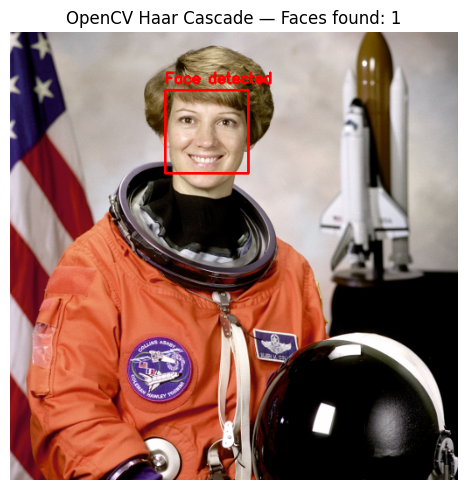

Bounding boxes: [[177  66  95  95]]
Note: detection outputs coordinates (x, y, width, height), not an identity.


In [11]:
import cv2
from skimage import data as skdata

# Load a sample image (astronaut face from scikit-image)
img_rgb = skdata.astronaut()
gray    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Haar cascade face detector
cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

img_out = img_rgb.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(img_out, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.putText(img_out, 'Face detected', (x, y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 0, 0), 2)

plt.figure(figsize=(6, 5))
plt.imshow(img_out)
plt.title(f'OpenCV Haar Cascade — Faces found: {len(faces)}')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Bounding boxes: {faces}')
print('Note: detection outputs coordinates (x, y, width, height), not an identity.')

### 6.1 Why detection matters for privacy

The Haar cascade tells me **where** a face is in the frame. It does not identify **who** the person is. This is an important distinction for hospital deployment: a PPE compliance system only needs to know 'is this face wearing a mask?' — not whose face it is. Using detection + classification rather than facial recognition avoids collecting biometric identity data, which reduces HIPAA exposure and patient consent requirements.

## 7. Reflection

**Q1 — What is the difference between classification and detection?**

Classification answers "what is in this image?" given a single cropped input. Detection answers "where are the objects in this scene?" by scanning the full image and returning bounding boxes. In my pipeline, ResNet-18 handles classification — it receives a 224×224 face crop and outputs a `mask_on`/`mask_off` label. A real deployment would first run a detector (like OpenCV or YOLO) to locate face regions, then pass each crop to my classifier.

**Q2 — Why would a hospital prefer mask detection over identity recognition?**

PPE compliance monitoring only needs to know whether a mask is present — not who the person is. Identity recognition would require storing and processing biometric data, triggering HIPAA obligations and staff consent requirements. Detection-only avoids that entirely: the system never learns or stores anyone's identity, which is both legally safer and more ethically defensible.

**Q3 — Three risks of deploying vision systems in clinical spaces**

1. **Distribution shift** — the model achieved 100% accuracy on a clean, controlled test set, but real hospital cameras capture varied lighting, angles, and mask types. Performance in the field will almost certainly be lower, and that gap is invisible until monitored.
2. **Demographic bias** — if training data underrepresents certain skin tones or mask styles, accuracy may be lower for those groups, leading to inequitable enforcement.
3. **Alert fatigue** — if false positives accumulate in real-world deployment, staff begin ignoring alerts, which defeats the safety purpose of the system entirely.

**Q4 — Recommended guardrails**

See the Deployment Note in Section 8 below.

## 8. Deployment Risk Analysis and Guardrails

**False Positive Risk — missed unmasked person**

If my model incorrectly clears someone who isn't wearing a mask, that person could enter a sterile or high-risk area unprotected. In a surgical ward or ICU, this could expose immunocompromised patients to respiratory pathogens. The harm is direct and potentially irreversible — a patient could contract a hospital-acquired infection that compounds their existing condition. This is the error type I'd prioritise minimising in deployment.

**False Negative Risk — unnecessary alert**

If my model incorrectly flags a masked staff member, they get interrupted and asked to verify their PPE. On its own this is manageable, but if false alarms happen frequently, staff start ignoring alerts — a phenomenon called alert fatigue. That erodes the reliability of the entire monitoring system and is itself a patient safety risk.

**Guardrails I'd add before deployment**

*Human review and escalation:* I'd configure any model alert to notify a charge nurse or security station rather than trigger an automated action. A human confirms the flag before anything happens. This keeps clinical judgment in the loop and prevents a model error from disrupting care delivery.

*Monitoring and performance tracking:* I'd log every prediction with a timestamp, camera zone, and confidence score. A weekly audit would compare flagged events against manual spot-checks to estimate real-world false positive and false negative rates. If recall for `mask_off` drops below 90%, I'd retrain before the next deployment cycle.

*Privacy and data governance:* Camera feeds would be processed in real time with no storage beyond a 24-hour rolling buffer. I'd never extract or retain facial identity data. Staff would be informed through posted signage that AI-assisted PPE monitoring is active, and the system would undergo an annual privacy impact assessment aligned with HIPAA technical safeguard requirements.

*Post-deployment data collection:* I'd use the human review workflow itself as a labelling pipeline — every alert a reviewer confirms or overrides becomes a new training sample. Over time this builds a dataset of real in-hospital images covering the actual lighting, camera angles, and mask types the model encounters, making future retraining much more targeted.